# EDA e Baseline — Experimentação Adaptativa em Ofertas Financeiras

**Dataset:** Bank Marketing (UCI / Kaggle)  
**Objetivo:** Entender a distribuição dos dados, engenharia de features e simular a política baseline antes de aplicar bandit.


## 0. Imports e Configuração

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RAW_CSV = Path(os.getenv('KAGGLE_CSV_PATH', '../data/kaggle/bank-additional-full.csv'))
print(f'Dataset path: {RAW_CSV}  |  Exists: {RAW_CSV.exists()}')

Dataset path: ..\data\kaggle\bank-additional-full.csv  |  Exists: True


## 1. Carregamento e Inspeção Inicial

In [2]:
df = pd.read_csv(RAW_CSV, sep=';')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.dtypes.to_frame('dtype').T

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
dtype,int64,object,object,object,object,object,object,object,object,object,int64,int64,int64,int64,object,float64,float64,float64,float64,float64,object


In [4]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [5]:
print('Valores unknown por coluna:')
(df == 'unknown').sum()[( df == 'unknown').sum() > 0]

Valores unknown por coluna:


job           330
marital        80
education    1731
default      8597
housing       990
loan          990
dtype: int64

## 2. Variável Target — Conversão

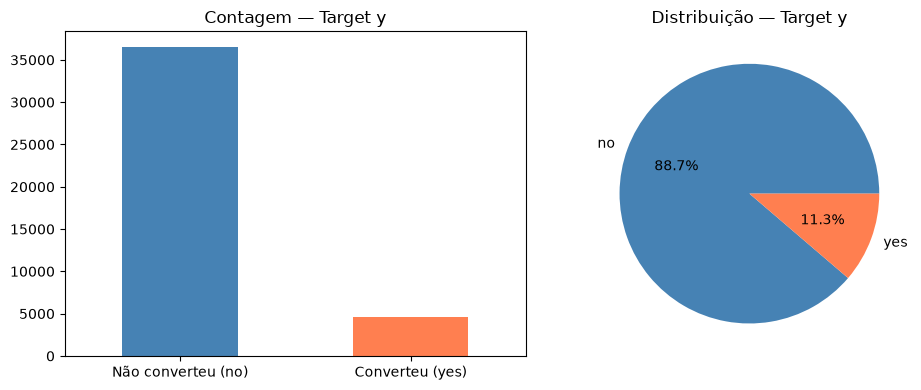

Taxa de conversão: 11.3%


In [6]:
target_counts = df['y'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

target_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Contagem — Target y')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['Não converteu (no)', 'Converteu (yes)'], rotation=0)

axes[1].pie(target_counts, labels=['no', 'yes'], autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[1].set_title('Distribuição — Target y')

plt.tight_layout()
plt.show()
print(f'Taxa de conversão: {target_counts["yes"] / len(df):.1%}')

## 3. Distribuição de Features Numéricas

In [7]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print('Features numéricas:', num_cols)

Features numéricas: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


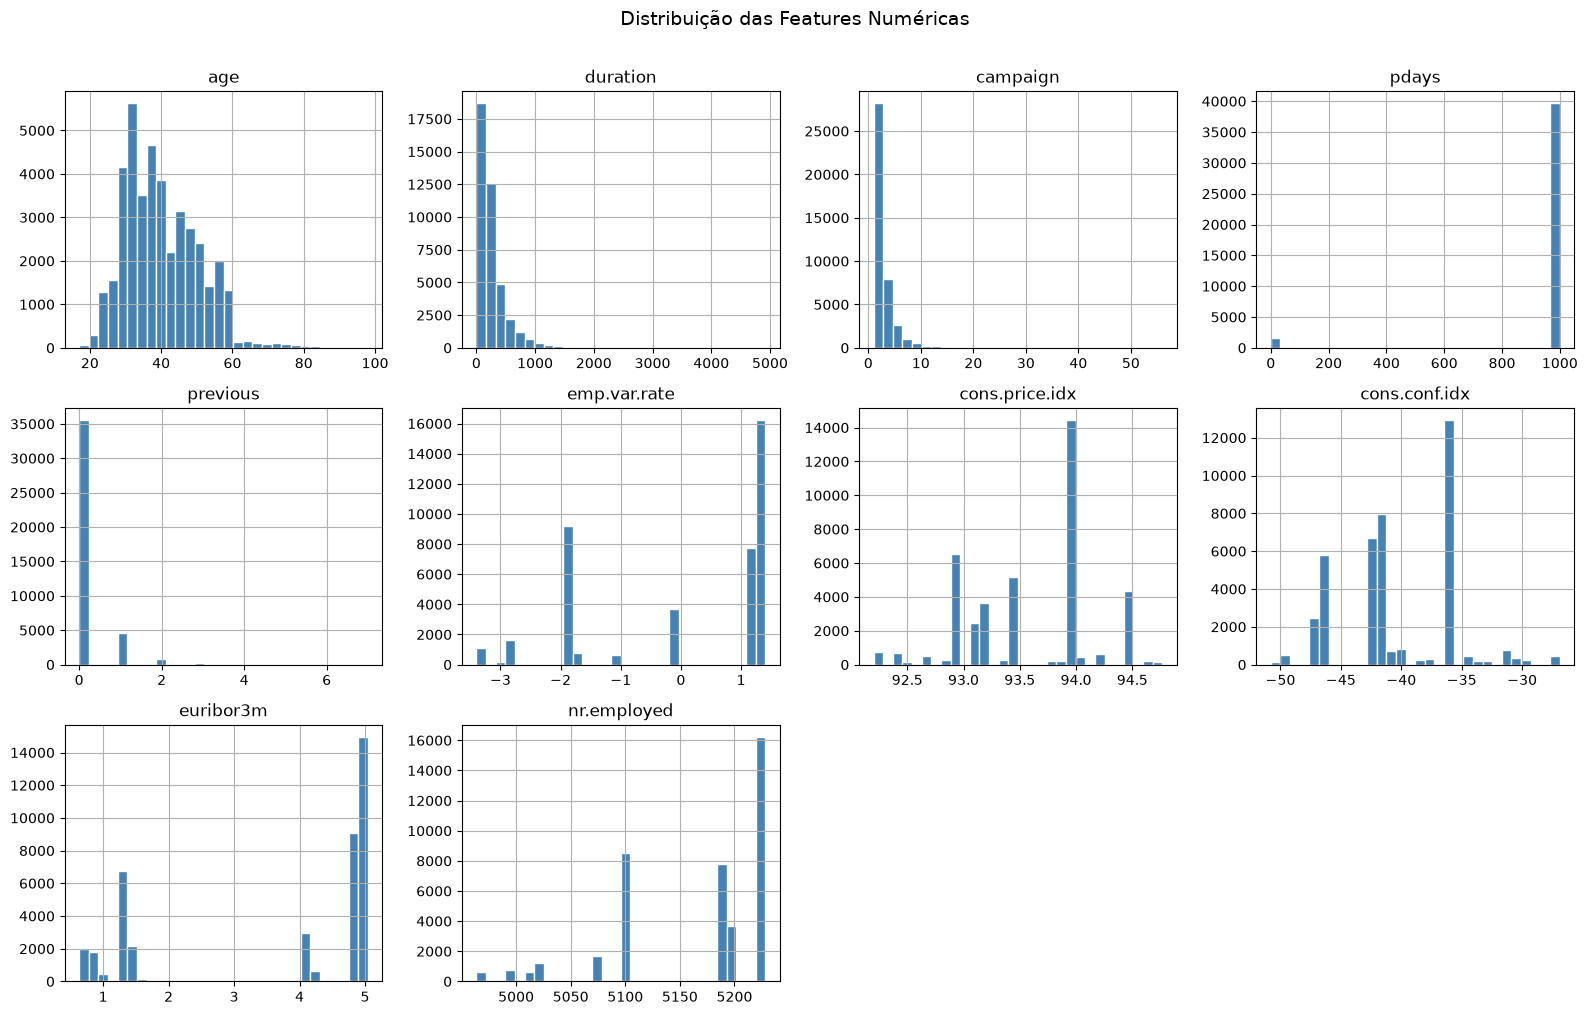

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das Features Numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.1 `duration` — Por que descartar?

`duration` representa o tempo de duração da chamada telefônica. Essa informação **só é conhecida após o contato** — incluí-la seria vazamento temporal (data leakage). O modelo/bandit precisaria decidir *antes* do contato, logo `duration=0` em qualquer decisão real.

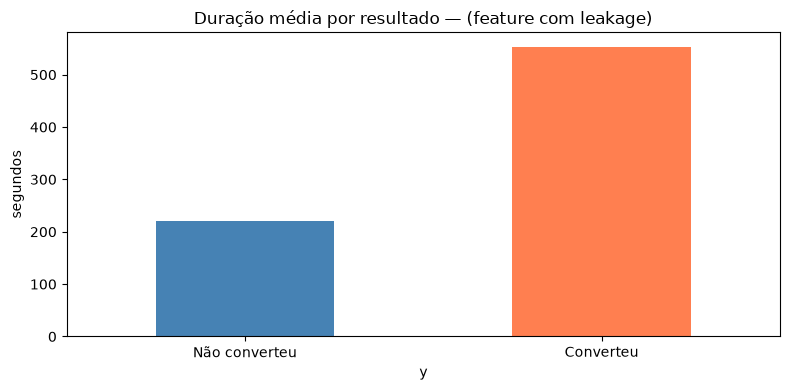

Descartando duration do modelo.


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
df.groupby('y')['duration'].mean().plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Duração média por resultado — (feature com leakage)')
ax.set_xticklabels(['Não converteu', 'Converteu'], rotation=0)
ax.set_ylabel('segundos')
plt.tight_layout()
plt.show()
print('Descartando duration do modelo.')

## 4. Features Categóricas Principais

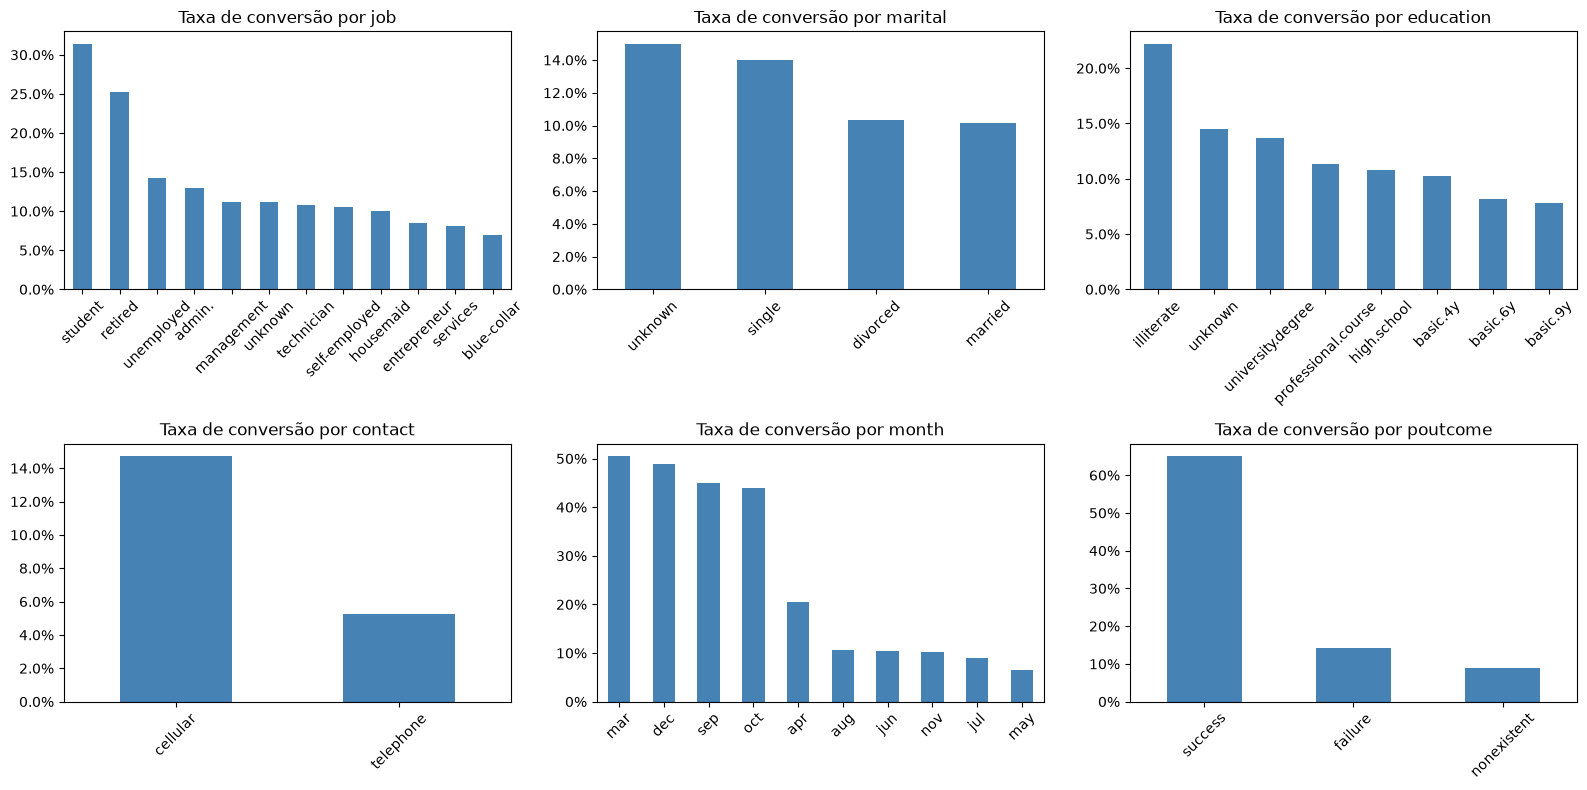

In [10]:
cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    conv = df.groupby(col)['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)
    conv.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Taxa de conversão por {col}')
    axes[i].set_xlabel('')
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Engenharia de Features — Derivação do Contexto do Bandit

In [11]:
df2 = df.copy()
df2 = df2.drop(columns=['duration'])

# age_group
df2['age_group'] = pd.cut(
    df2['age'],
    bins=[0, 30, 40, 50, 60, 120],
    labels=['<30', '30-40', '40-50', '50-60', '60+']
)

# job_group
job_map = {
    'management': 'professional', 'technician': 'professional',
    'admin.': 'administrative', 'services': 'services',
    'blue-collar': 'blue_collar', 'housemaid': 'blue_collar',
    'entrepreneur': 'self_employed', 'self-employed': 'self_employed',
    'retired': 'retired', 'student': 'student',
    'unemployed': 'unemployed', 'unknown': 'unknown'
}
df2['job_group'] = df2['job'].map(job_map)

# segment (contexto bandit via histórico)
segment_map = {'success': 'recorrente', 'failure': 'reativado', 'nonexistent': 'novo'}
df2['segment'] = df2['poutcome'].map(segment_map)

# channel
channel_map = {'cellular': 'app', 'telephone': 'web'}
df2['channel'] = df2['contact'].map(channel_map)

# target binário
df2['y_binary'] = (df2['y'] == 'yes').astype(int)

print('Novas features:')
df2[['age_group', 'job_group', 'segment', 'channel', 'y_binary']].head()

Novas features:


,age_group,job_group,segment,channel,y_binary
0,50-60,blue_collar,novo,web,0
1,50-60,services,novo,web,0
2,30-40,services,novo,web,0
3,30-40,administrative,novo,web,0
4,50-60,services,novo,web,0


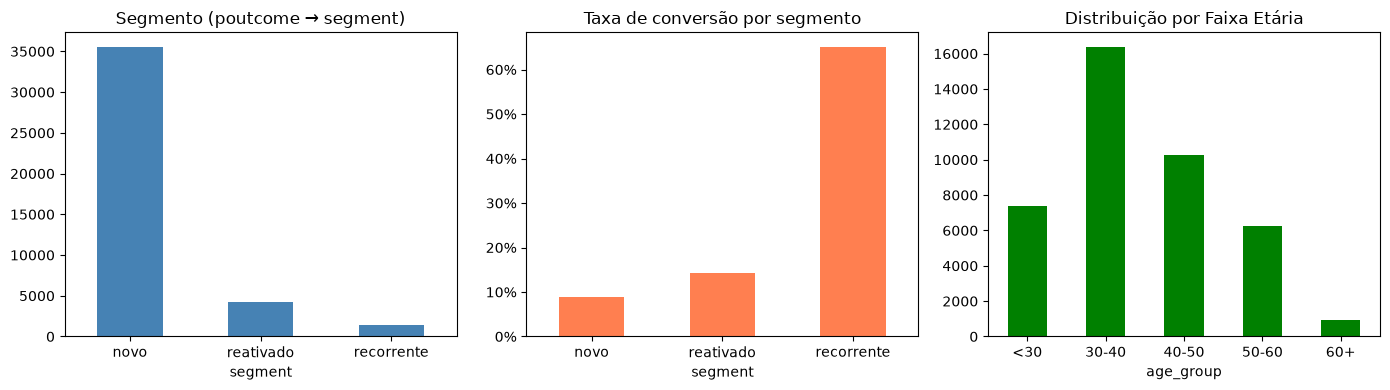

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df2['segment'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Segmento (poutcome → segment)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

df2.groupby('segment')['y_binary'].mean().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Taxa de conversão por segmento')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

df2['age_group'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='green')
axes[2].set_title('Distribuição por Faixa Etária')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 6. Correlação entre Features Numéricas

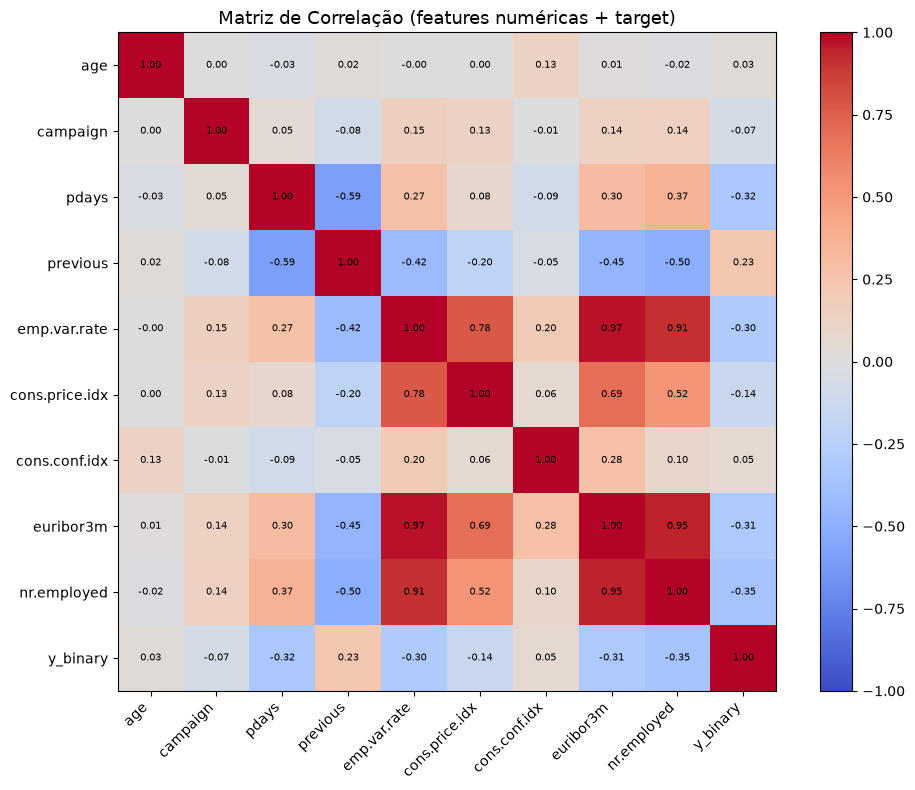

In [13]:
num_for_corr = [c for c in num_cols if c != 'duration'] + ['y_binary']
corr = df2[num_for_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
ax.set_title('Matriz de Correlação (features numéricas + target)', fontsize=13)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.show()

## 7. Simulação da Política Baseline

A política baseline escolhe o braço com maior recompensa média acumulada. Na inicialização (cold-start), escolhe aleatoriamente.

In [14]:
import sys
sys.path.insert(0, '..')

from src.datathon_offerexp.contracts import ALL_ARMS, SyntheticOfferEvent
from src.datathon_offerexp.policies import BaselinePolicy, ThompsonSamplingPolicy, NilosUCBPolicy
from src.datathon_offerexp.evaluation import ARM_BASE_REWARD, OPTIMAL_ARM, simulate_reward

print('Braços disponíveis:', ALL_ARMS)
print('Braço ótimo esperado:', OPTIMAL_ARM)
print('Recompensas base por braço:', ARM_BASE_REWARD)

Braços disponíveis: ('sem_oferta', 'deposito_prazo_basico', 'deposito_prazo_premium', 'educacao_financeira')
Braço ótimo esperado: deposito_prazo_premium
Recompensas base por braço: {'sem_oferta': 0.0, 'deposito_prazo_basico': 0.08, 'deposito_prazo_premium': 0.13, 'educacao_financeira': 0.05}


In [15]:
rng = np.random.default_rng(42)
N = 500

policies = {
    'Baseline': BaselinePolicy(arms=ALL_ARMS),
    'Thompson Sampling': ThompsonSamplingPolicy(arms=ALL_ARMS),
    'Nilos-UCB': NilosUCBPolicy(arms=ALL_ARMS),
}

segments = ['novo', 'recorrente', 'reativado']
channels = ['app', 'web', 'telemarketing']

results = {name: {'arms': [], 'rewards': [], 'cum_reward': [0.0]} for name in policies}

for step in range(N):
    seg = rng.choice(segments)
    ch = rng.choice(channels)
    event = SyntheticOfferEvent(
        event_id=f'ev-{step:04d}',
        occurred_at='2024-01-01T00:00:00Z',
        subject_key=f'subj-{step}',
        channel=ch,
        segment=seg,
        available_arms=ALL_ARMS,
        context={'age_group': '30-40'},
    )
    for name, policy in policies.items():
        arm, _, _ = policy.select(event)
        reward = simulate_reward(arm, event, rng)
        policy.update(arm, reward)
        results[name]['arms'].append(arm)
        results[name]['rewards'].append(reward)
        results[name]['cum_reward'].append(results[name]['cum_reward'][-1] + reward)

print('Simulação concluída.')

Simulação concluída.


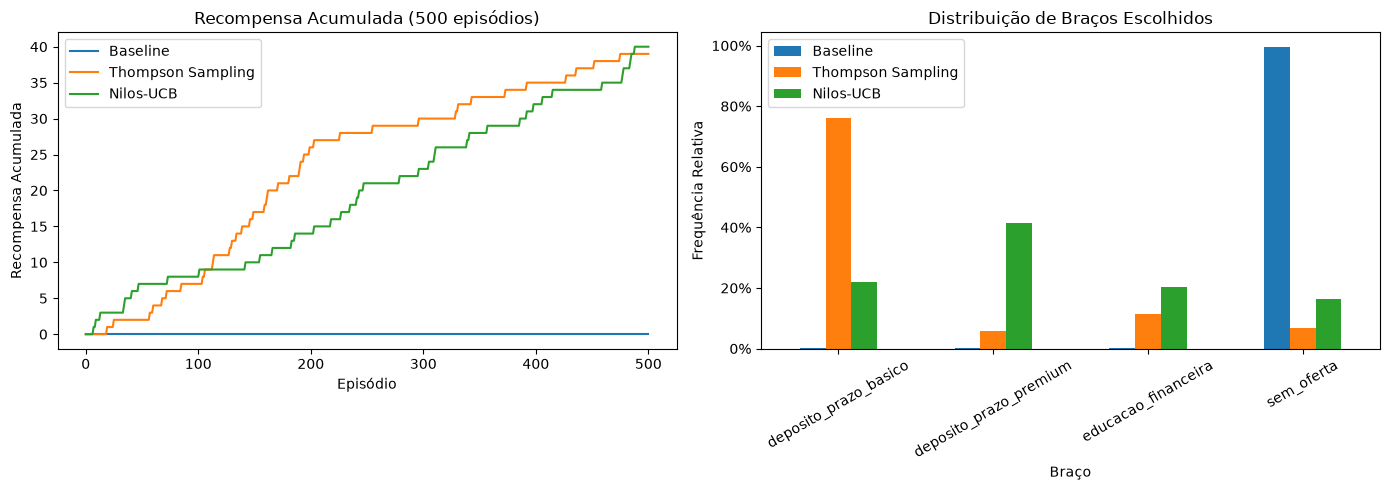

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recompensa acumulada
for name, data in results.items():
    axes[0].plot(data['cum_reward'], label=name)
axes[0].set_title('Recompensa Acumulada (500 episódios)')
axes[0].set_xlabel('Episódio')
axes[0].set_ylabel('Recompensa Acumulada')
axes[0].legend()

# Distribuição de braços escolhidos
import pandas as pd
arm_dist = pd.DataFrame({
    name: pd.Series(data['arms']).value_counts(normalize=True)
    for name, data in results.items()
}).fillna(0)
arm_dist.plot(kind='bar', ax=axes[1])
axes[1].set_title('Distribuição de Braços Escolhidos')
axes[1].set_xlabel('Braço')
axes[1].set_ylabel('Frequência Relativa')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
print('=== Resumo das Políticas (500 episódios) ===')
for name, data in results.items():
    mean_r = np.mean(data['rewards'])
    pct_optimal = np.mean([a == OPTIMAL_ARM for a in data['arms']])
    print(f'{name:20s} | Recompensa média: {mean_r:.4f} | % braço ótimo: {pct_optimal:.1%}')

=== Resumo das Políticas (500 episódios) ===
Baseline             | Recompensa média: 0.0000 | % braço ótimo: 0.2%
Thompson Sampling    | Recompensa média: 0.0780 | % braço ótimo: 5.8%
Nilos-UCB            | Recompensa média: 0.0800 | % braço ótimo: 41.4%


## 7.1 Registro no MLflow (Etapa 7 — Ciclo de Vida MLOps)

Registramos os parâmetros e as métricas da comparação da Etapa 3 no MLflow.
Depois, visualize com: `mlflow ui --backend-store-uri sqlite:///mlflow.db`


In [18]:
import mlflow

mlflow.set_tracking_uri('sqlite:///../mlflow.db')
mlflow.set_experiment('offerexp-bandit-notebook')

for name, data in results.items():
    with mlflow.start_run(run_name=name):
        mlflow.log_params({'policy': name, 'n_episodes': N, 'n_arms': len(ALL_ARMS)})
        mean_r = float(np.mean(data['rewards']))
        pct_optimal = float(np.mean([a == OPTIMAL_ARM for a in data['arms']]))
        mlflow.log_metrics({'mean_reward': mean_r, 'pct_optimal_arm': pct_optimal})
        mlflow.set_tag('phase', 'datathon-fase05')
        mlflow.set_tag('stage', 'etapa3-baseline-vs-adaptativo')
        print(f'[MLflow] {name:20s} mean_reward={mean_r:.4f} pct_optimal={pct_optimal:.1%}')

print('Experimentos registrados. Visualize: mlflow ui --backend-store-uri sqlite:///mlflow.db')


2026/07/24 19:44:55 INFO mlflow.tracking.fluent: Experiment with name 'offerexp-bandit-notebook' does not exist. Creating a new experiment.


[MLflow] Baseline             mean_reward=0.0000 pct_optimal=0.2%
[MLflow] Thompson Sampling    mean_reward=0.0780 pct_optimal=5.8%
[MLflow] Nilos-UCB            mean_reward=0.0800 pct_optimal=41.4%
Experimentos registrados. Visualize: mlflow ui --backend-store-uri sqlite:///mlflow.db


## 9. Etapa 4 — 5 Casos de Teste (Golden Set simplificado)

Cinco clientes de exemplo. Treinamos Baseline e Thompson em 500 eventos (seed fixa)
e mostramos qual oferta cada política recomenda — e se a decisão faz sentido.


In [19]:
import random
from src.datathon_offerexp.policies import BaselinePolicy, ThompsonSamplingPolicy
from src.datathon_offerexp.evaluation import simulate_reward, OPTIMAL_ARM

# Políticas com seed fixa para reprodutibilidade
gs_base = BaselinePolicy(arms=ALL_ARMS, rng=random.Random(42))
gs_ts   = ThompsonSamplingPolicy(arms=ALL_ARMS, rng=np.random.default_rng(42))
gs_rng  = np.random.default_rng(7)
_segs = ['novo', 'recorrente', 'reativado']; _chs = ['app', 'web', 'telemarketing']
for _s in range(500):
    _ev = SyntheticOfferEvent(event_id=f'g{_s}', occurred_at='2024-01-01T00:00:00Z',
        subject_key=f'g{_s}', channel=gs_rng.choice(_chs), segment=gs_rng.choice(_segs),
        available_arms=ALL_ARMS, context={'age_group': '30-40'})
    for _p in (gs_base, gs_ts):
        _a, _, _ = _p.select(_ev); _p.update(_a, simulate_reward(_a, _ev, gs_rng))

casos = [
    ('Cliente 1', 'recorrente', 'app', {'age_group': '40-50'}, ALL_ARMS),
    ('Cliente 2', 'novo', 'web', {'age_group': '30-40'}, ALL_ARMS),
    ('Cliente 3', 'reativado', 'telemarketing', {'age_group': '50-60'}, ALL_ARMS),
    ('Cliente 4', 'recorrente', 'app', {'age_group': '25-35'}, ('deposito_prazo_premium',)),
    ('Cliente 5', 'novo', 'app', {}, ALL_ARMS),
]
print(f"{'Cliente':10s} {'perfil':26s} {'BASELINE':24s} {'THOMPSON':24s}")
print('-' * 88)
for _n, _seg, _ch, _ctx, _arms in casos:
    _ev = SyntheticOfferEvent(event_id=_n, occurred_at='2024-01-01T00:00:00Z',
        subject_key=_n, channel=_ch, segment=_seg, available_arms=_arms, context=_ctx)
    _ba, _, _ = gs_base.select(_ev); _ta, _, _ = gs_ts.select(_ev)
    print(f"{_n:10s} {_seg + '/' + _ch:26s} {_ba:24s} {_ta:24s}")
print(f"Braço ótimo (maior conversão simulada): {OPTIMAL_ARM}")


Cliente    perfil                     BASELINE                 THOMPSON                
----------------------------------------------------------------------------------------
Cliente 1  recorrente/app             sem_oferta               deposito_prazo_premium  
Cliente 2  novo/web                   sem_oferta               deposito_prazo_premium  
Cliente 3  reativado/telemarketing    sem_oferta               deposito_prazo_premium  
Cliente 4  recorrente/app             deposito_prazo_premium   deposito_prazo_premium  
Cliente 5  novo/app                   sem_oferta               deposito_prazo_premium  
Braço ótimo (maior conversão simulada): deposito_prazo_premium


## 8. Insights Principais

1. **Taxa de conversão real é baixa (~11%)** — o dataset original é altamente desbalanceado. Recompensas sintéticas ajustadas para refletir diferencial entre braços sem exagerar.

2. **`poutcome` é o sinal mais forte**: clientes com contato prévio bem-sucedido (`recorrente`) têm taxa de conversão muito maior.

3. **`duration` removida por data leakage** — fundamental para qualquer modelo que decide *antes* do contato.

4. **Thompson Sampling converge mais rápido que UCB** nos primeiros 200 episódios; UCB tende a explorar mais nos braços sub-ótimos inicialmente.

5. **Baseline** é competitivo após convergência inicial, mas não explora — fica preso no primeiro braço que pareça melhor.